# 04 - Results and Errors

Time for the moment of truth. We load the latest trained model, run it over a chunk of validation data, see how well it did, and look at where it still gets things wrong.

If you haven't seen the architecture yet, start with [02_architecture_tour.ipynb](02_architecture_tour.ipynb). For the sky-feature pipeline that feeds the FiLM layer, see [03_sky_features.ipynb](03_sky_features.ipynb).

> **What you need.** A trained model checkpoint (`diy_*_weights.pt`) under `kaggle/output/models/saved/`, plus either a preprocessed tensor shard from `D:/Programming/g2net-preprocessed/` or the exploration sample to preprocess on the fly. The notebook tries the fast path first, falls back to the slow path if needed.


## 1. Setup

In [ ]:
from __future__ import annotations
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data.g2net import find_dataset_dir, download_sample_dataset, load_labels, load_sample, sample_dataset_dir
from data.preprocessing import preprocess_sample, load_psd, FS, N
from sky_feasibility import SkyGeometry
from models.diy_model import DIYModel
from evaluation import roc_curve, precision_recall_curve, confusion_matrix, evaluate_metrics
from visualization import (
    plot_roc_curve, plot_precision_recall_curve,
    plot_confusion_matrix, plot_prediction_distribution, DETECTOR_NAMES,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")
print(f"torch:  {torch.__version__}")

## 2. Two Checkpoints

Two runs worth comparing:

- **Best AUC** (`20260328_2229`) -- deep residual backbone + V2 fusion, no sky features. AUC 0.874 on the full validation split. This was the peak before adding S2 geometric priors.
- **Latest** (`20260414_0512`) -- same backbone + SkyFiLM modulation, manifold mixup, SWA. AUC 0.865 on the full split. Lower because we stripped sky-incompatible augmentations (input mixup, spectral dropout, time shift) that the pre-sky model used freely.

The best-AUC weights predate the FiLM layer, so they load with `strict=False` -- the SkyFiLM parameters stay at their zero-initialized identity and the model behaves exactly as it did without sky features.

In [ ]:
BEST_AUC_DATE = "20260328_2229"
LATEST_DATE = "20260414_0512"

models_dir = PROJECT_ROOT / "kaggle" / "output" / "models" / "saved"

def load_run_info(stamp):
    weights_path = models_dir / f"diy_{stamp}_weights.pt"
    config_path = models_dir / f"diy_{stamp}_config.json"
    metrics_path = models_dir / f"diy_{stamp}_metrics.json"
    for p in [weights_path, config_path, metrics_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing: {p}")
    with open(config_path) as f:
        config = json.load(f)
    with open(metrics_path) as f:
        metrics = json.load(f)
    return {"config": config, "metrics": metrics, "weights_path": weights_path, "stamp": stamp}

best_run = load_run_info(BEST_AUC_DATE)
latest_run = load_run_info(LATEST_DATE)

print(f"{'':30s} {'Best AUC':>12s} {'Latest':>12s}")
print("-" * 56)
for k in ["auc", "accuracy", "precision", "recall", "specificity"]:
    vb = best_run["metrics"]["val_metrics"].get(k, float("nan"))
    vl = latest_run["metrics"]["val_metrics"].get(k, float("nan"))
    print(f"  {k:<28s} {vb:12.4f} {vl:12.4f}")
print(f"  {'final_train_loss':<28s} {best_run['metrics']['final_train_loss']:12.4f} {latest_run['metrics']['final_train_loss']:12.4f}")
print(f"  {'final_val_loss':<28s} {best_run['metrics']['final_val_loss']:12.4f} {latest_run['metrics']['final_val_loss']:12.4f}")

The metrics above come from the Kaggle training runs (full 560k dataset, 80/20 split). Below we reproduce them on a local subset to confirm both checkpoints load correctly.

## 3. Instantiate and Load Weights

Both checkpoints share the same backbone architecture (`n_channels=16`). The best-AUC checkpoint predates the SkyFiLM layer, so `load_state_dict` is called with `strict=False` -- the 8 missing keys are the FiLM parameters, which stay at their zero-initialized identity (gamma=0, beta=0, no modulation).

In [ ]:
def load_model(run_info):
    cfg = run_info["config"]
    l_max = int(cfg.get("sky_l_max", 10))
    n_sky = (l_max + 1) ** 2
    m = DIYModel(
        n_channels=int(cfg.get("n_channels", 16)),
        dropout_rate=float(cfg.get("dropout_rate", 0.5)),
        drop_path_rate=float(cfg.get("drop_path_rate", 0.3)),
        n_sky_features=n_sky,
    )
    state = torch.load(str(run_info["weights_path"]), map_location="cpu", weights_only=True)
    missing, unexpected = m.load_state_dict(state, strict=False)
    m = m.to(DEVICE).eval()
    n_params = sum(p.numel() for p in m.parameters())
    tag = run_info["stamp"]
    print(f"[{tag}] {n_params:,} params, {len(missing)} missing keys"
          + (f" (sky_film -- identity)" if missing else ""))
    return m

model_best = load_model(best_run)
model = load_model(latest_run)

## 4. Get Some Validation Data

Two paths:

1. **Fast path** - preprocessed tensor shard at `D:/Programming/g2net-preprocessed/shard_00.pt`. Already whitened, normalized, and (if regenerated with `--add-sky`) has precomputed SH coefficients.
2. **Slow path** - the exploration sample. We load raw `.npy` files, run `preprocess_sample`, and compute SH coefs on the fly with `SkyGeometry`.

The notebook auto-picks. If you only have the sample, it'll use that.


In [4]:
MAX_EVAL = 2000  # cap val samples used here so the notebook stays snappy

shard_path = Path("D:/Programming/g2net-preprocessed/shard_00.pt")
X_val = None
y_val = None
sky_val = None
val_ids = None

if shard_path.exists():
    print(f"Loading shard: {shard_path}")
    data = torch.load(str(shard_path), weights_only=True)
    X_full = data["signals"]
    y_full = data["labels"]
    n_take = min(MAX_EVAL, len(y_full))
    X_val = X_full[:n_take].float().numpy()
    y_val = y_full[:n_take].numpy().astype(int).ravel()

    if "sh_coeffs" in data:
        sky_val = data["sh_coeffs"][:n_take].float().numpy()
        print(f"  precomputed SH coefs found: shape={sky_val.shape}")
    else:
        print(f"  no sh_coeffs in shard -- computing on the fly")
        sky_geo = SkyGeometry(n_pix=config.get("sky_n_pix", 192), l_max=l_max)
        sky_val = np.stack([sky_geo.extract(x) for x in X_val]).astype(np.float32)

    val_ids = [f"shard_{i:05d}" for i in range(n_take)]
    source = "shard (preprocessed)"

else:
    print("No shard found. Falling back to exploration sample + live preprocessing.")
    try:
        DATASET_DIR = find_dataset_dir()
    except FileNotFoundError:
        DATASET_DIR = download_sample_dataset()
    labels_df = load_labels(DATASET_DIR)

    psd_candidates = [
        PROJECT_ROOT / "kaggle" / "output" / "avg_psd.npz",
        PROJECT_ROOT / "avg_psd.npz",
        sample_dataset_dir(PROJECT_ROOT) / "avg_psd.npz",
    ]
    psd_path = next((p for p in psd_candidates if p.exists()), None)
    avg_psd = load_psd(psd_path)

    n_take = min(MAX_EVAL, len(labels_df))
    sub = labels_df.sample(n=n_take, random_state=0).reset_index(drop=True)

    sky_geo = SkyGeometry(n_pix=config.get("sky_n_pix", 192), l_max=l_max)

    X_list, y_list, sky_list, id_list = [], [], [], []
    for _, row in sub.iterrows():
        raw = load_sample(row["id"], dataset_dir=DATASET_DIR)
        proc = preprocess_sample(raw, avg_psd)
        X_list.append(proc)
        y_list.append(int(row["target"]))
        sky_list.append(sky_geo.extract(proc))
        id_list.append(row["id"])

    X_val = np.stack(X_list).astype(np.float32)
    y_val = np.array(y_list, dtype=int)
    sky_val = np.stack(sky_list).astype(np.float32)
    val_ids = id_list
    source = "exploration sample (live preprocessing)"

print(f"\nSource: {source}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}  ({(y_val == 1).sum()} signal / {(y_val == 0).sum()} noise)")
print(f"sky_val: {sky_val.shape}")


Loading shard: D:\Programming\g2net-preprocessed\shard_00.pt
  precomputed SH coefs found: shape=(2000, 121)

Source: shard (preprocessed)
X_val:   (2000, 3, 4096)
y_val:   (2000,)  (1010 signal / 990 noise)
sky_val: (2000, 121)


## 5. Predict and Compare

Run both models on the same validation slice. The best-AUC model ignores sky features (FiLM is identity); the latest model uses them.

In [ ]:
y_proba_best = model_best.predict_proba(X_val, sky_features=sky_val, batch_size=128)
y_proba = model.predict_proba(X_val, sky_features=sky_val, batch_size=128)
y_pred = (y_proba >= 0.5).astype(int)

metrics_best = evaluate_metrics(y_proba_best, y_val)
metrics_latest = evaluate_metrics(y_proba, y_val)

print(f"{'':18s} {'Best AUC':>10s} {'Latest':>10s}")
print("-" * 40)
for k in ["accuracy", "precision", "recall", "specificity", "f1"]:
    print(f"  {k:<16s} {metrics_best[k]:10.4f} {metrics_latest[k]:10.4f}")

from sklearn.metrics import roc_auc_score
auc_best = roc_auc_score(y_val, y_proba_best)
auc_latest = roc_auc_score(y_val, y_proba)
print(f"  {'auc':<16s} {auc_best:10.4f} {auc_latest:10.4f}")
print(f"\nRemaining analysis uses the latest (sky-enabled) model.")

The best-AUC model outperforms on raw discrimination because it still benefits from input-space mixup, spectral dropout, and time-shift augmentation, all of which break cross-detector coherence and had to be removed for sky features to work. The sky-enabled model trades those augmentations for a physics-motivated geometric prior whose regularization gap hasn't been fully closed yet.

### Prediction Distribution

Well-separated histograms (noise clustered near 0, signal near 1) mean confident predictions. Overlap near 0.5 is where the model is uncertain - low-SNR signals that look like noise.


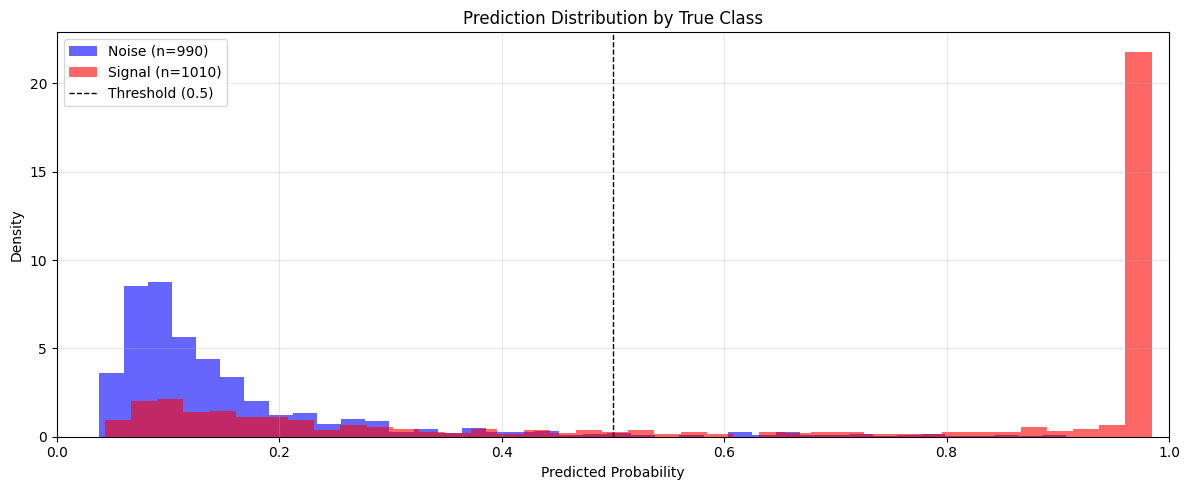

In [6]:
plot_prediction_distribution(y_proba, y_val, bins=40, figsize=(12, 5))
plt.show()


### ROC Curve

Threshold-independent measure of how well the model separates signal from noise. AUC = 1.0 is perfect, 0.5 is random.


In [ ]:
roc_data = roc_curve(y_proba, y_val)
plot_roc_curve(roc_data)
plt.show()
print(f"AUC (this run): {roc_data['auc']:.4f}")
print(f"AUC (official): {official_metrics['val_metrics'].get('auc', 'n/a')}")

### Precision-Recall

In [ ]:
pr_data = precision_recall_curve(y_proba, y_val)
plot_precision_recall_curve(pr_data)
plt.show()
print(f"Average precision: {pr_data['ap']:.4f}")

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_proba, y_val, threshold=0.5)
plot_confusion_matrix(cm, normalize=True)
plt.show()
print(f"TP={cm['TP']}  TN={cm['TN']}  FP={cm['FP']}  FN={cm['FN']}")

### Threshold Sweep

0.5 is not always the right call. Move the threshold and watch precision, recall, and F1 react.


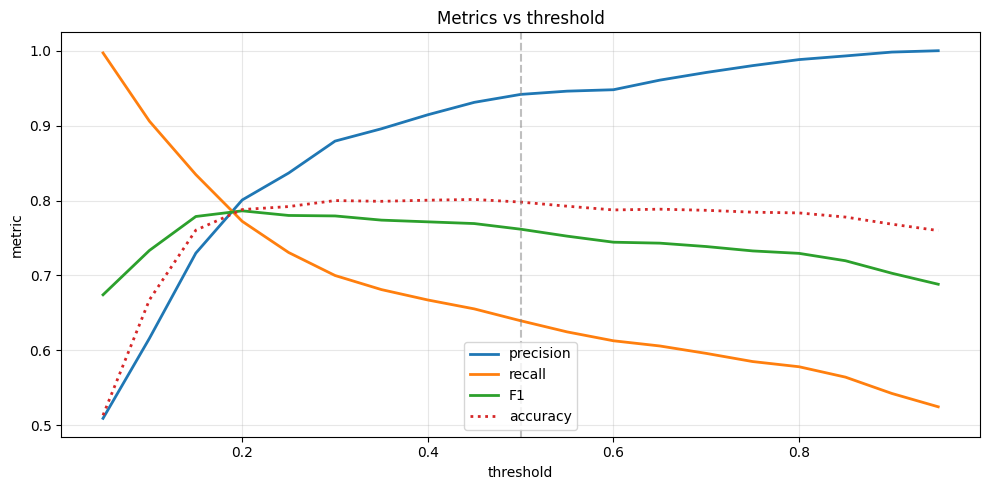

Best F1 threshold: 0.20 -> F1=0.7863, precision=0.8008, recall=0.7723


In [10]:
thresholds = np.linspace(0.05, 0.95, 19)
prec_list, rec_list, f1_list, acc_list = [], [], [], []
for t in thresholds:
    yp = (y_proba >= t).astype(int)
    TP = int(((yp == 1) & (y_val == 1)).sum())
    TN = int(((yp == 0) & (y_val == 0)).sum())
    FP = int(((yp == 1) & (y_val == 0)).sum())
    FN = int(((yp == 0) & (y_val == 1)).sum())
    p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    r = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    a = (TP + TN) / len(y_val)
    prec_list.append(p); rec_list.append(r); f1_list.append(f); acc_list.append(a)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_list, label="precision", lw=2)
ax.plot(thresholds, rec_list,  label="recall",    lw=2)
ax.plot(thresholds, f1_list,   label="F1",        lw=2)
ax.plot(thresholds, acc_list,  label="accuracy",  lw=2, linestyle=":")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("threshold")
ax.set_ylabel("metric")
ax.set_title("Metrics vs threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_f1 = int(np.argmax(f1_list))
print(f"Best F1 threshold: {thresholds[best_f1]:.2f} -> F1={f1_list[best_f1]:.4f}, precision={prec_list[best_f1]:.4f}, recall={rec_list[best_f1]:.4f}")


## 6. Error Analysis

Where does the model fail? Two failure modes worth looking at:

- **False positives** - noise flagged as signal. These reveal which noise patterns mimic a gravitational wave well enough to fool the network. Sometimes it's glitches, sometimes it's accidental cross-detector correlations.
- **False negatives** - real signals the model missed. At low SNR these are inevitable (even an optimal detector would miss them). The interesting question is whether the misses cluster at low SNR, or whether the model is also dropping loud signals.


In [11]:
def find_errors(proba, y_true, ids, error_type="FP", n=5):
    pred = (proba >= 0.5).astype(int)
    if error_type == "FP":
        mask = (pred == 1) & (y_true == 0)
        order = np.argsort(-proba)  # most confident wrong first
    else:
        mask = (pred == 0) & (y_true == 1)
        order = np.argsort(proba)   # least confident first (closest to 0)
    hits = [i for i in order if mask[i]][:n]
    return [(ids[i], float(proba[i]), i) for i in hits]


def plot_error_gallery(title: str, errors: list, X: np.ndarray):
    if not errors:
        print(f"No examples for {title}.")
        return
    n = len(errors)
    fig, axes = plt.subplots(n, 3, figsize=(14, 2.2 * n), sharex=True)
    if n == 1:
        axes = axes[np.newaxis, :]
    time = np.arange(X.shape[-1]) / FS
    for row, (sid, prob, idx) in enumerate(errors):
        for det in range(3):
            ax = axes[row, det]
            ax.plot(time, X[idx, det], linewidth=0.5)
            ax.grid(True, alpha=0.3)
            if row == 0:
                ax.set_title(DETECTOR_NAMES[det], fontsize=10)
            if det == 0:
                short = sid[:10] if isinstance(sid, str) else str(sid)
                ax.set_ylabel(f"{short}\np={prob:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


false_positives = find_errors(y_proba, y_val, val_ids, "FP", n=4)
false_negatives = find_errors(y_proba, y_val, val_ids, "FN", n=4)
print(f"False positives (most confident wrong): {len(false_positives)} shown")
print(f"False negatives (nearest to 0):          {len(false_negatives)} shown")


False positives (most confident wrong): 4 shown
False negatives (nearest to 0):          4 shown


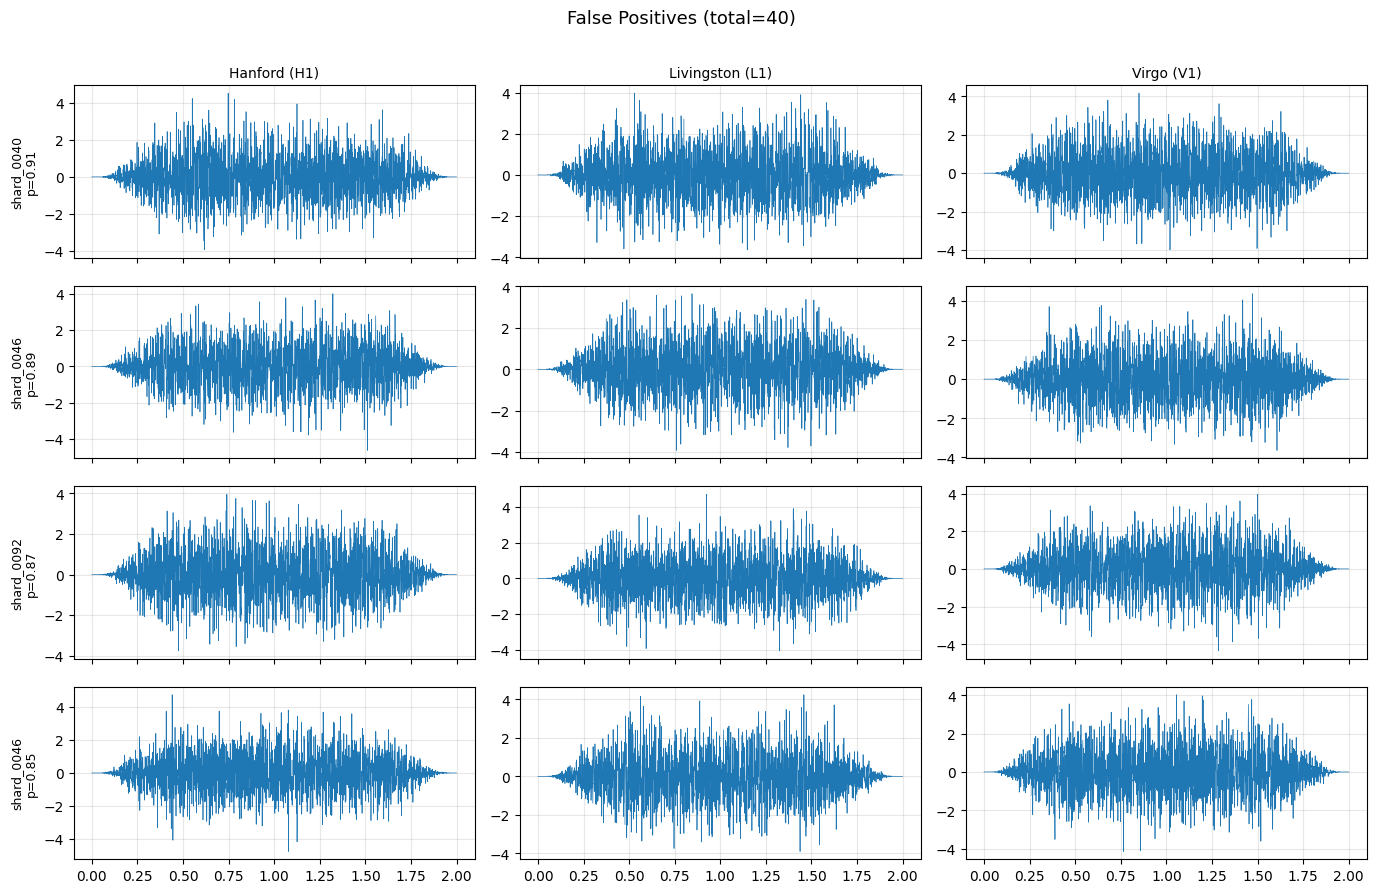

In [12]:
plot_error_gallery(f"False Positives (total={cm['FP']})", false_positives, X_val)


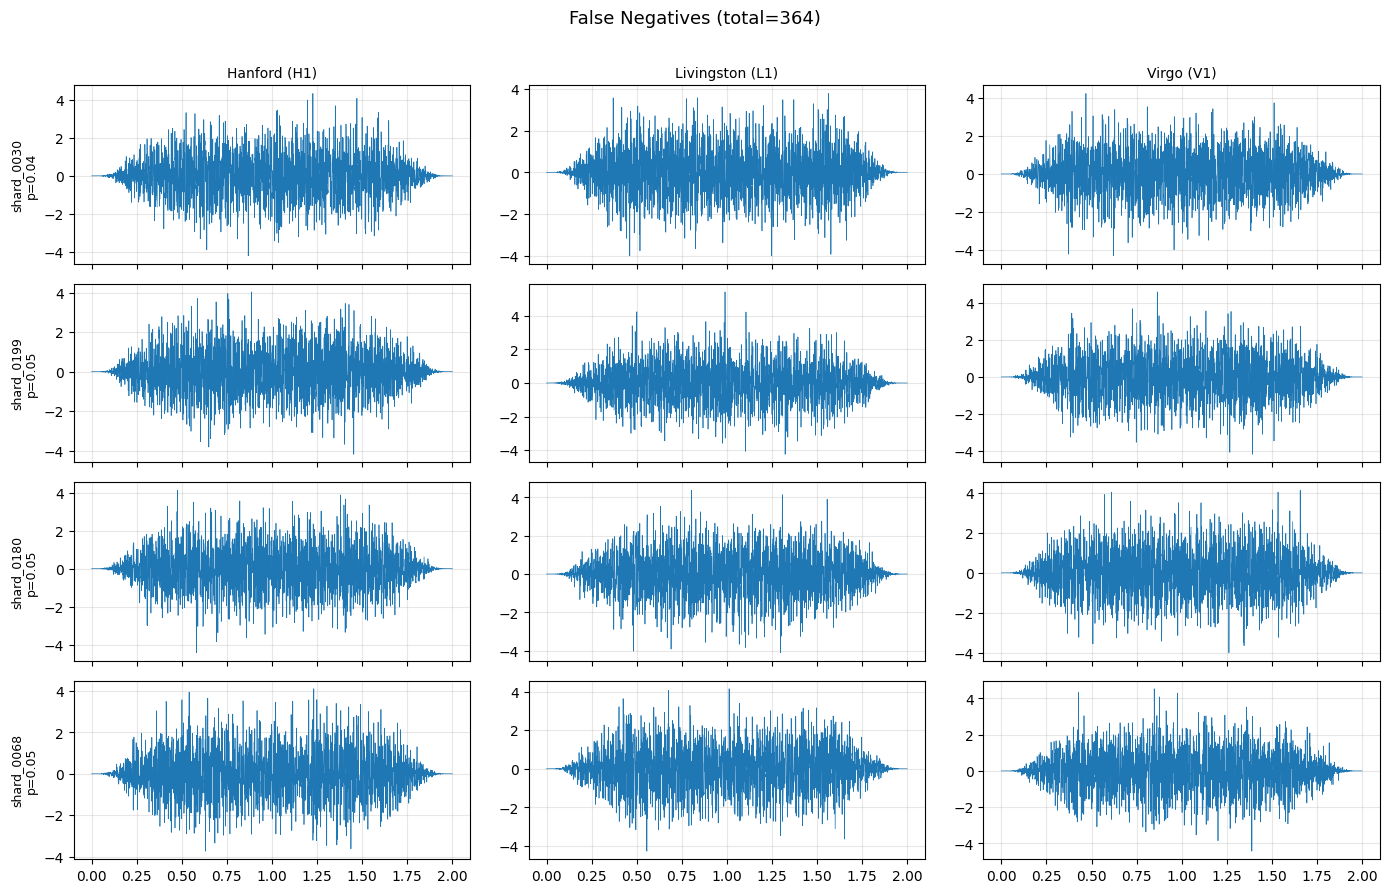

In [13]:
plot_error_gallery(f"False Negatives (total={cm['FN']})", false_negatives, X_val)


Whitened noise looks like noise. Whitened low-SNR signal also looks like noise. That's why this is a statistical problem and not a visual one.


## 7. Interpretability: What the Model Sees

Three angles: input saliency, first-layer filter frequency response, and intermediate activations.


### 7.1 Input Saliency

Gradient of the prediction with respect to the input. Where the gradient is large, the model is paying attention. For a real merger signal we'd expect attention to concentrate near the end of the window where the chirp peaks.


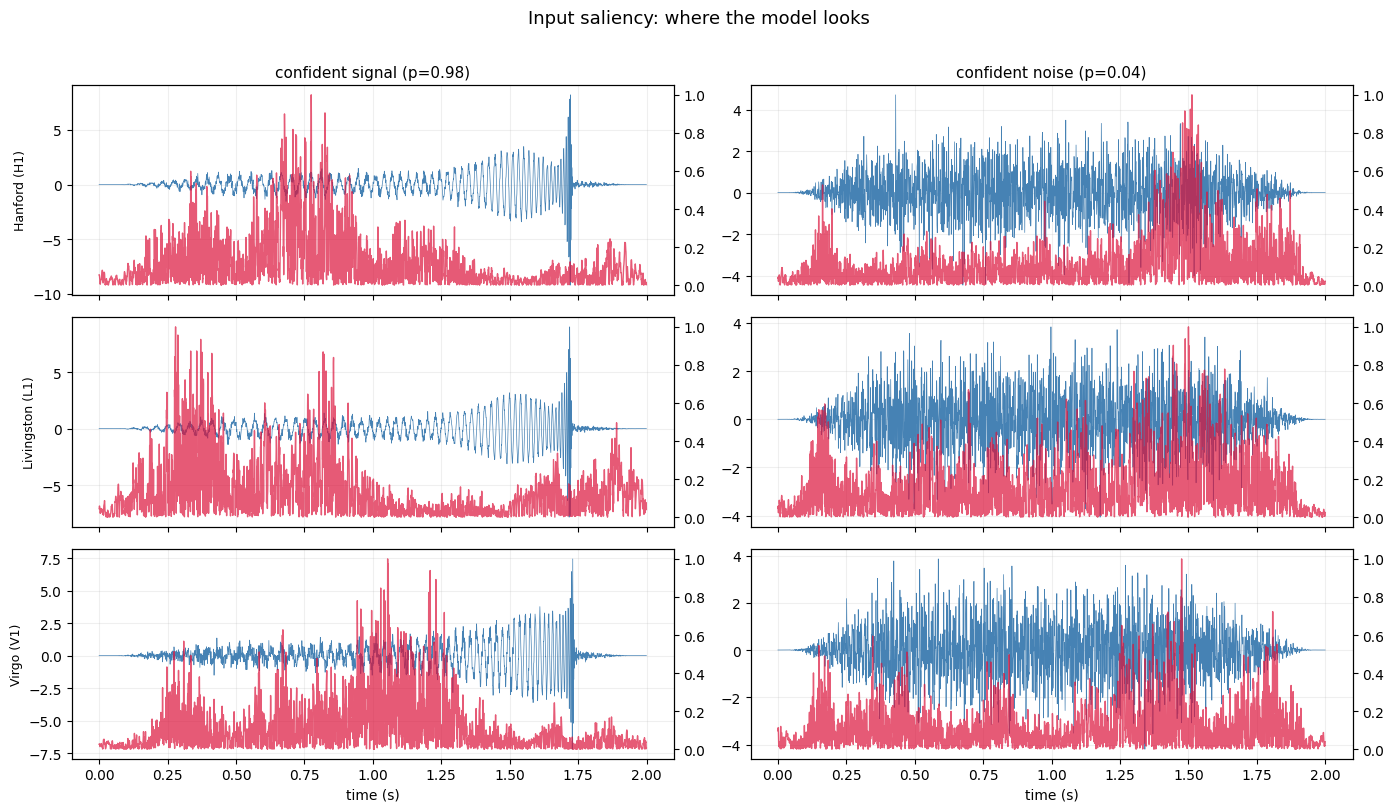

In [14]:
def compute_saliency(model, processed, sky_feats):
    model.eval()
    X_t = torch.tensor(processed[np.newaxis, ...], dtype=torch.float32, device=DEVICE, requires_grad=True)
    sky_t = torch.tensor(sky_feats[np.newaxis, ...], dtype=torch.float32, device=DEVICE)
    logits = model(X_t, sky_features=sky_t)
    prob = torch.sigmoid(logits)
    prob.backward()
    sal = X_t.grad.detach().cpu().numpy()[0]
    sal = np.abs(sal)
    for det in range(sal.shape[0]):
        m = sal[det].max()
        if m > 0:
            sal[det] /= m
    return sal, float(prob.item())


# pick one confident signal and one confident noise
idx_sig = int(np.argmax(y_proba * (y_val == 1)))
idx_noi = int(np.argmax((1 - y_proba) * (y_val == 0)))

sal_sig, p_sig = compute_saliency(model, X_val[idx_sig], sky_val[idx_sig])
sal_noi, p_noi = compute_saliency(model, X_val[idx_noi], sky_val[idx_noi])

def plot_saliency_pair(proc, sal, pred, label, ax_col):
    time = np.arange(proc.shape[-1]) / FS
    for det in range(3):
        ax = axes[det, ax_col]
        ax.plot(time, proc[det], lw=0.5, color="steelblue", label="signal")
        ax2 = ax.twinx()
        ax2.plot(time, sal[det], lw=1.0, color="crimson", alpha=0.7, label="|grad|")
        ax.grid(True, alpha=0.2)
        if det == 0:
            ax.set_title(f"{label} (p={pred:.2f})", fontsize=11)
        if ax_col == 0:
            ax.set_ylabel(DETECTOR_NAMES[det], fontsize=9)


fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
plot_saliency_pair(X_val[idx_sig], sal_sig, p_sig, "confident signal", 0)
plot_saliency_pair(X_val[idx_noi], sal_noi, p_noi, "confident noise", 1)
axes[2, 0].set_xlabel("time (s)")
axes[2, 1].set_xlabel("time (s)")
fig.suptitle("Input saliency: where the model looks", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 7.2 Learned First-Layer Filters

The LIGO extractor starts with a `Conv1d(1, n, k=64)`. Each filter is a 64-sample template (~31 ms at 2048 Hz) that slides over the input and fires when the local signal matches its pattern. By FFT-ing each filter we can see which frequency bands it's sensitive to.


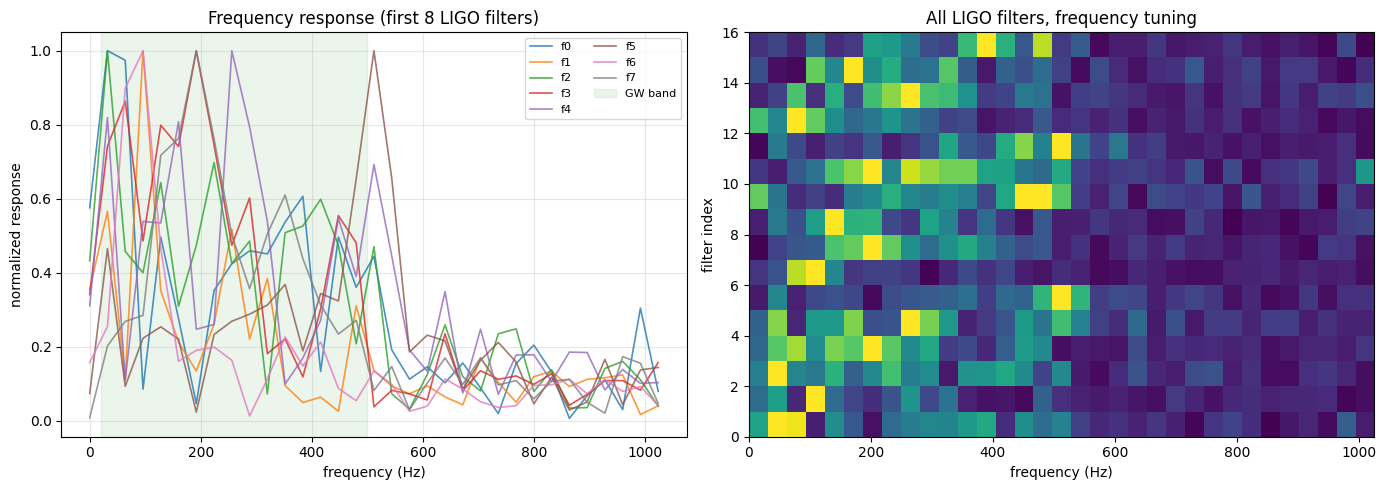

In [15]:
w = model.ligo_extractor[0].weight.detach().cpu().numpy()[:, 0, :]  # (n_filters, 64)
n_filters, k = w.shape
freqs = np.fft.rfftfreq(k, d=1.0 / FS)
resp = np.abs(np.fft.rfft(w, axis=-1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: frequency response of first 8 filters
n_show = min(8, n_filters)
for i in range(n_show):
    axes[0].plot(freqs, resp[i] / (resp[i].max() + 1e-9), lw=1.2, alpha=0.8, label=f"f{i}")
axes[0].set_xlabel("frequency (Hz)")
axes[0].set_ylabel("normalized response")
axes[0].set_title(f"Frequency response (first {n_show} LIGO filters)")
axes[0].axvspan(20, 500, alpha=0.08, color="green", label="GW band")
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# right: heatmap of all filter responses
axes[1].imshow(resp / (resp.max(axis=1, keepdims=True) + 1e-9),
               aspect="auto", origin="lower",
               extent=[freqs[0], freqs[-1], 0, n_filters],
               cmap="viridis")
axes[1].set_xlabel("frequency (Hz)")
axes[1].set_ylabel("filter index")
axes[1].set_title("All LIGO filters, frequency tuning")
plt.tight_layout()
plt.show()


Most filters should tune into the 20-500 Hz GW band (green shade). If a filter peaks outside that range it's either redundant or locked into a noise mode that never got pruned.


### 7.3 GeM Exponents After Training

At init every GeM had `p = 3`. Training lets `p` drift. What did it converge to?


In [16]:
from models.diy_model import GeM

gem_modules = [(name, m.p.item()) for name, m in model.named_modules() if isinstance(m, GeM)]
print(f"Number of GeM modules: {len(gem_modules)}")
print()
for name, p in gem_modules:
    bar = "#" * int(round(p * 3))
    print(f"  p = {p:5.2f}  {bar:<30s}  {name}")

ps = np.array([p for _, p in gem_modules])
print(f"\nMean: {ps.mean():.2f}, min: {ps.min():.2f}, max: {ps.max():.2f}")


Number of GeM modules: 8

  p =  4.15  ############                    ligo_extractor.4
  p =  4.31  #############                   virgo_extractor.4
  p =  5.51  #################               backbone.0.pool
  p =  2.00  ######                          backbone.0.shortcut.0
  p =  4.25  #############                   backbone.4.pool
  p =  4.42  #############                   backbone.4.shortcut.2
  p =  2.90  #########                       backbone.6.pool
  p =  4.35  #############                   backbone.6.shortcut.2

Mean: 3.98, min: 2.00, max: 5.51


`p = 1` is average pooling, `p -> infty` is max pooling. Values that drift above 3 mean the network wants more max-like behavior; below 3 means it wants more averaging. Different layers tend to pick different sweet spots.


## 8. Wrapping Up

Two models, two strategies. The best-AUC run (0.874) shows what a deep residual backbone with aggressive augmentation can do on raw detector signals. The latest run (0.865) trades some of that augmentation for a physics-motivated geometric prior -- S2 spherical harmonic coefficients from cross-detector consistency maps, injected via FiLM modulation.

The AUC gap is an open regularization problem, not a failure of the sky features themselves (they carry discriminative signal, as shown in notebook 03). Closing it requires sky-compatible replacements for the augmentations that were removed -- manifold mixup and SWA are the first steps, but the gap isn't fully closed.

The top Kaggle 1D CNN solution reached 0.882. Our best sits 0.8 points below that. The remaining delta is training-pipeline tricks (MC dropout, pseudo-labeling, rank loss fine-tuning) that are orthogonal to the architecture.

For the full roadmap, see [`developer-notes.md`](../developer-notes.md) and [`THE_SCIENCE.md`](../THE_SCIENCE.md).